In [10]:
# ==========================================
# CELL-0. NOTEBOOK MIGRATION STATUS
# ==========================================
# Save current success state
!jupyter nbconvert --to notebook --output marmousi_delta_inversion.ipynb openfwi_delta_experiment.ipynb
print("SUCCESS: Notebook cloned. You are now working in 'marmousi_delta_inversion.ipynb'.")

SUCCESS: Notebook cloned. You are now working in 'marmousi_delta_inversion.ipynb'.


[NbConvertApp] Converting notebook openfwi_delta_experiment.ipynb to notebook
[NbConvertApp] Writing 165731 bytes to marmousi_delta_inversion.ipynb


In [11]:
# ==========================================
# CELL-1. HARDWARE & INITIALIZATION
# ==========================================
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import deepwave
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="deepwave")
print("System Warnings: SUPPRESSED.")

# Initialize Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

System Warnings: SUPPRESSED.
HPC Node Active: cuda



Extracting Raw SEG-Y & Applying Physical Corrections...
Extraction Complete. Computational Grid: 70 x 70 (dx = 10m)


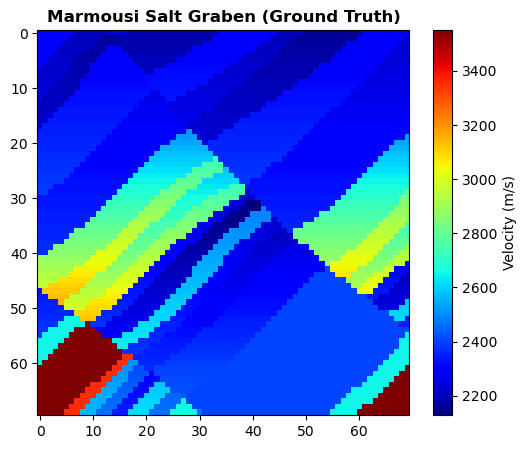

In [18]:
# ==========================================
# CELL-2. DATA INGESTION & THE MICROSCOPE STRATEGY
# ==========================================
import os
import segyio
import numpy as np
import matplotlib.pyplot as plt

# Raw SEG-Y Ingestion
segy_path = os.path.join("data/vp_marmousi-ii", "vp_marmousi-ii.segy")

print("Extracting Raw SEG-Y & Applying Physical Corrections...")
with segyio.open(segy_path, ignore_geometry=True, strict=False) as segy_file:
    marmousi_raw = np.array(segy_file.trace.raw[:], dtype=np.float32)

# Correct AGL km/s to m/s
marmousi_vp_ms = marmousi_raw * 1000.0

# The Microscope Strategy: Extract 700x700m Graben & Decimate to 10m grid
x_start, z_start = 7200, 800
step = 8
patch_vp = marmousi_vp_ms[x_start:x_start+560:step, z_start:z_start+560:step]

nx, nz = patch_vp.shape
dx, dz = 10.0, 10.0
print(f"Extraction Complete. Computational Grid: {nx} x {nz} (dx = 10m)")

# Verification
plt.figure(figsize=(6, 5))
im = plt.imshow(patch_vp.T, cmap='jet', aspect='auto')
plt.title("Marmousi Salt Graben (Ground Truth)", fontweight='bold')
plt.colorbar(im, label="Velocity (m/s)")
plt.show()

MVM Prior generated with sigma=1.5


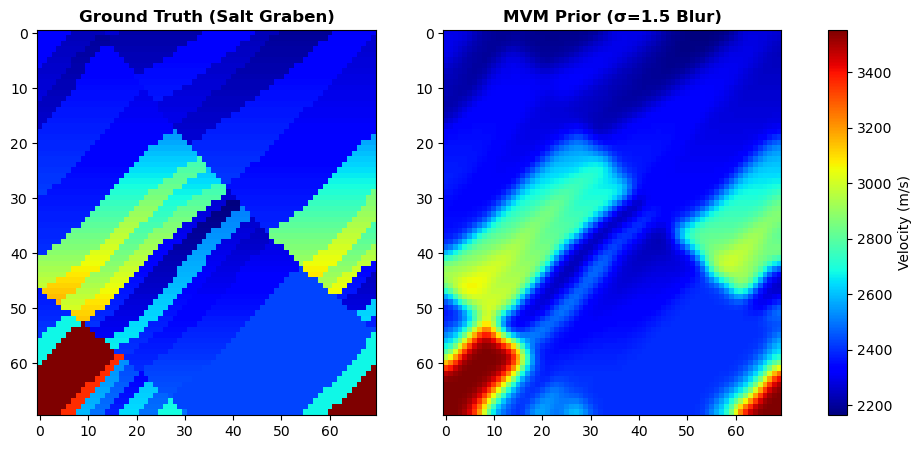

In [19]:
# ==========================================
# CELL-3. MARMOUSI PRIOR SYNTHESIS (TIGHTENED)
# ==========================================
import scipy.ndimage as ndimage

# Use a tighter sigma for the more complex Marmousi dip-structure
sigma_blur = 1.5 
mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=sigma_blur)

print(f"MVM Prior generated with sigma={sigma_blur}")

# Visual Validation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(patch_vp.T, cmap='jet', aspect='auto')
axes[0].set_title("Ground Truth (Salt Graben)", fontweight='bold')
im = axes[1].imshow(mvm_vp.T, cmap='jet', aspect='auto')
axes[1].set_title(f"MVM Prior (σ={sigma_blur} Blur)", fontweight='bold')
fig.colorbar(im, ax=axes.ravel().tolist(), label="Velocity (m/s)")
plt.show()

In [21]:
# ==========================================
# CELL-4. PHYSICAL PARAMETERS & ACQUISITION SETUP
# ==========================================
# Physics Parameters
dt, nt, dx = 0.001, 1000, 10.0
num_shots, num_receivers = 21, 70

# Source & Receiver coordinates (700m width model)
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = torch.linspace(5, nx - 5, num_shots).long()
source_locations[:, 0, 1] = 2 # Shallow source

receiver_locations = torch.zeros(num_shots, num_receivers, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = torch.arange(0, nx).repeat(num_shots, 1)
receiver_locations[:, :, 1] = 2 # Shallow receivers

# Coordinate Grid for Fourier-Feature Mapping
x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(nz, dtype=torch.float32), indexing='ij')
x_flat = (x_grid.flatten().unsqueeze(1) / nx).to(device)
z_flat = (z_grid.flatten().unsqueeze(1) / nz).to(device)

print(f"Marmousi Geometry: {num_shots} shots, {num_receivers} receivers/shot.")
print("SUCCESS: Acquisition grid mapped to complex Marmousi graben.")

Marmousi Geometry: 21 shots, 70 receivers/shot.
SUCCESS: Acquisition grid mapped to complex Marmousi graben.


In [22]:
# ==========================================
# CELL-5. ARCHITECTURAL DEFINITION & LOSS FUNCTIONS
# ==========================================
class FourierDeltaPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Multi-scale Fourier features to capture complex salt/sediment dips
        self.scales = [1.0, 5.0, 10.0, 20.0]
        self.B = nn.Parameter(torch.randn(2, 64) * 10.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128 * len(self.scales), 512), nn.Mish(),
            nn.Linear(512, 512), nn.Mish(),
            nn.Linear(512, 256), nn.Mish(),
            nn.Linear(256, 1)
        )
        
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        features = []
        for s in self.scales:
            proj = (2.0 * np.pi * s * coords) @ self.B
            features.append(torch.sin(proj))
            features.append(torch.cos(proj))
        
        fourier_features = torch.cat(features, dim=1)
        # Scaled output to allow for +/- 1000 m/s velocity corrections
        return 1000.0 * self.net(fourier_features)

# Essential TV Loss function to prevent blurring across salt boundaries
def balanced_tv_loss(velocity_grid, weight_x=1.0, weight_z=1.0):
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

# Initialize the Network Object
v_net_delta = FourierDeltaPINN().to(device)

print("FourierDeltaPINN and TV Loss function successfully registered.")
print("SUCCESS: Ready to refine the Marmousi salt-body boundaries.")

FourierDeltaPINN and TV Loss function successfully registered.
SUCCESS: Ready to refine the Marmousi salt-body boundaries.


In [23]:
# ==========================================
# CELL-6. TENSOR PREPARATION & GRID MAPPING
# ==========================================
# Convert to tensors and move to device
v_true = torch.tensor(patch_vp, device=device)
v_mvm_tensor = torch.tensor(mvm_vp, device=device)

# Ensure dimensions are (nx, nz) for deepwave compatibility
# If your extraction creates a (nz, nx) shape, transpose accordingly:
if v_true.shape != (nx, nz):
    v_true = v_true.T
    v_mvm_tensor = v_mvm_tensor.T

print(f"Tensor Shapes - Ground Truth: {v_true.shape}, Prior: {v_mvm_tensor.shape}")

# Pre-calculate flat coordinate grid for network input
x_grid_indices = torch.arange(nx, device=device).float() / nx
z_grid_indices = torch.arange(nz, device=device).float() / nz
grid_z, grid_x = torch.meshgrid(z_grid_indices, x_grid_indices, indexing='ij')

x_flat = grid_x.flatten().unsqueeze(1)
z_flat = grid_z.flatten().unsqueeze(1)

print("SUCCESS: Tensors initialized and coordinate grid flattened for PINN.")

Tensor Shapes - Ground Truth: torch.Size([70, 70]), Prior: torch.Size([70, 70])
SUCCESS: Tensors initialized and coordinate grid flattened for PINN.


In [31]:
# ==========================================
# CELL-7. STAGE 2: DELTA-NETWORK INVERSION (STABILIZED)
# ==========================================
import warnings
import torch.nn.functional as F

# Initialize tracking list
loss_history = []

# 1. Re-initialize the network
v_net_delta = FourierDeltaPINN().to(device)
optimizer_delta = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3) 
frequencies = [3.0, 8.0, 15.0, 25.0]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    for freq in frequencies:
        print(f"\n--- Optimizing at {freq} Hz ---")
        source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, 1.0/freq).reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
        
        with torch.no_grad():
            out_true = deepwave.scalar(v_true, grid_spacing=dx, dt=dt, 
                                       source_amplitudes=source_amplitudes, 
                                       source_locations=source_locations, 
                                       receiver_locations=receiver_locations)
            observed = out_true[-1].clone().detach()

        for epoch in range(200):
            optimizer_delta.zero_grad()
            
            # Physics-Informed Delta-Inversion
            delta_v = v_net_delta(x_flat, z_flat).reshape(nx, nz)
            delta_v = torch.clamp(delta_v, -1000.0, 1000.0) 
            v_final = v_mvm_tensor + delta_v
            
            out = deepwave.scalar(v_final, grid_spacing=dx, dt=dt, 
                                  source_amplitudes=source_amplitudes, 
                                  source_locations=source_locations, 
                                  receiver_locations=receiver_locations)
            
            # Use minimal TV weight for Marmousi's dipping structures
            tv_penalty = balanced_tv_loss(v_final, weight_x=1e-8, weight_z=1e-8)
            loss = F.mse_loss(out[-1], observed) + tv_penalty
            
            # Track the actual loss
            loss_history.append(loss.item())
            
            loss.backward()
            nn.utils.clip_grad_norm_(v_net_delta.parameters(), max_norm=0.5)
            optimizer_delta.step()
            
            if epoch % 50 == 0:
                print(f"Epoch {epoch} | MSE: {loss.item():.6f}")

print("\nSUCCESS: Marmousi Salt Graben Inversion Complete. Telemetry captured.")


--- Optimizing at 3.0 Hz ---
Epoch 0 | MSE: 0.081579
Epoch 50 | MSE: 0.002503
Epoch 100 | MSE: 0.002385
Epoch 150 | MSE: 0.002316

--- Optimizing at 8.0 Hz ---
Epoch 0 | MSE: 0.003274
Epoch 50 | MSE: 0.002300
Epoch 100 | MSE: 0.002200
Epoch 150 | MSE: 0.002099

--- Optimizing at 15.0 Hz ---
Epoch 0 | MSE: 0.002916
Epoch 50 | MSE: 0.002373
Epoch 100 | MSE: 0.002172
Epoch 150 | MSE: 0.002097

--- Optimizing at 25.0 Hz ---
Epoch 0 | MSE: 0.002403
Epoch 50 | MSE: 0.002145
Epoch 100 | MSE: 0.002033
Epoch 150 | MSE: 0.001976

SUCCESS: Marmousi Salt Graben Inversion Complete. Telemetry captured.


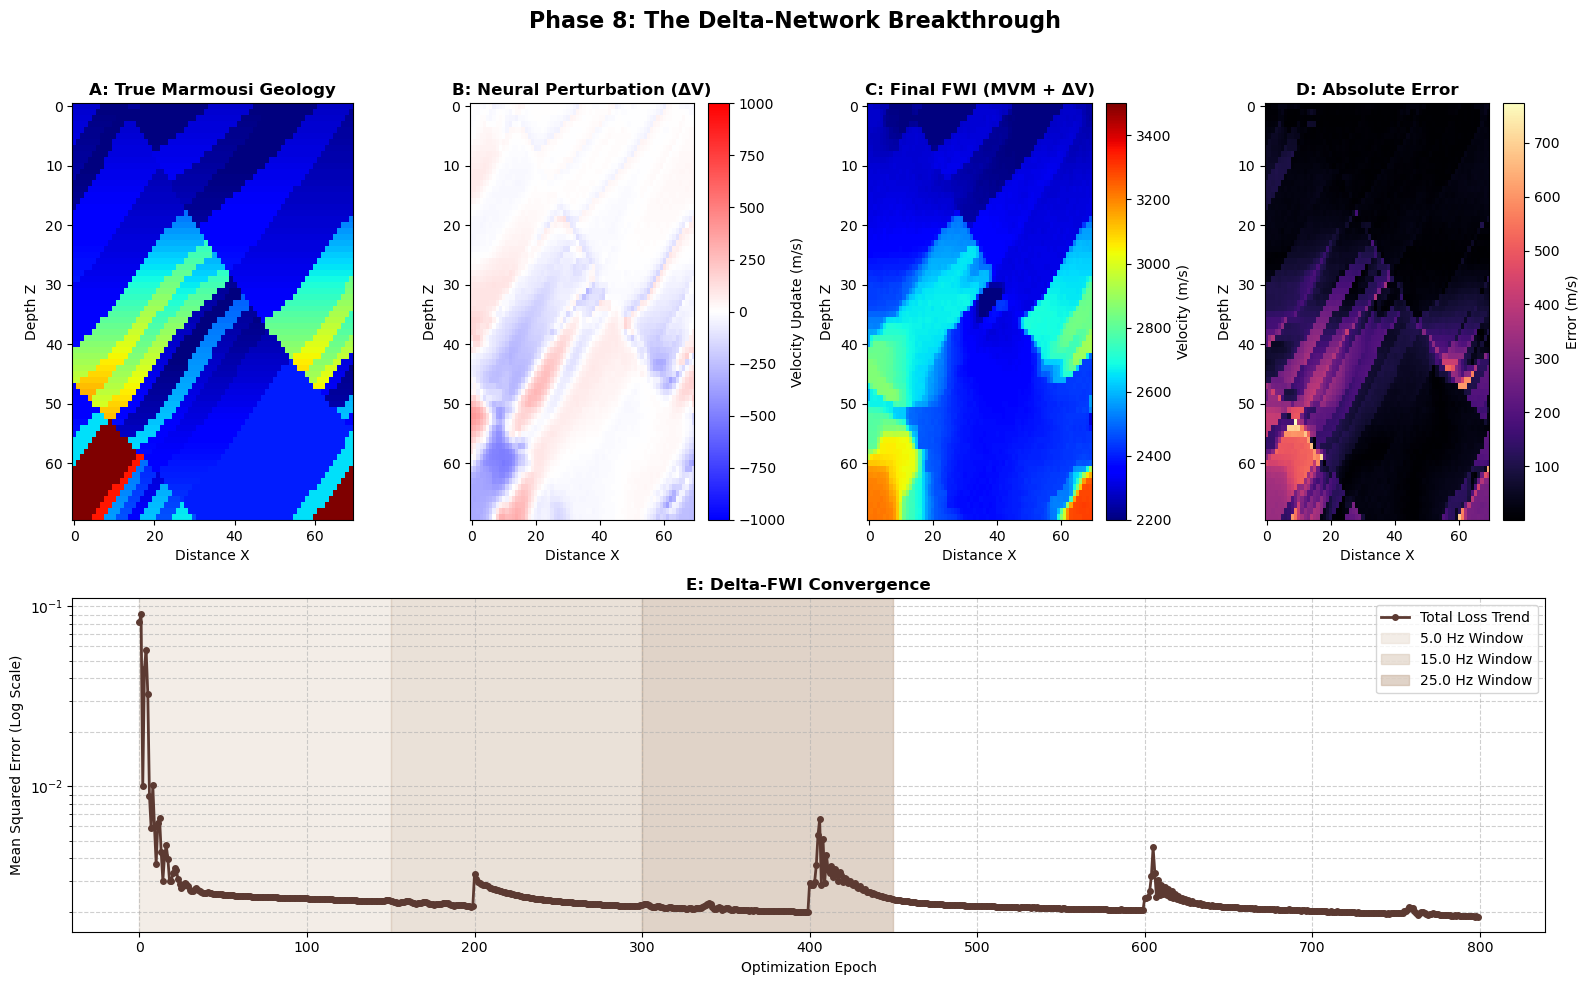

In [32]:
# ==========================================
# CELL-8. MARMOUSI RESULT VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Prepare Data
v_final_cpu = v_final.detach().cpu().numpy()
v_true_cpu = v_true.detach().cpu().numpy()
delta_v_cpu = v_net_delta(x_flat, z_flat).reshape(nx, nz).detach().cpu().numpy()
error_map = np.abs(v_final_cpu - v_true_cpu)

# Create Figure
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 0.8])

# Panel A: Ground Truth
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(v_true_cpu.T, cmap='jet', aspect='auto', vmin=2200, vmax=3500)
ax1.set_title("A: True Marmousi Geology", fontweight='bold')
ax1.set_xlabel("Distance X"); ax1.set_ylabel("Depth Z")

# Panel B: Neural Perturbation
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(delta_v_cpu.T, cmap='bwr', aspect='auto', vmin=-1000, vmax=1000)
ax2.set_title("B: Neural Perturbation (ΔV)", fontweight='bold')
ax2.set_xlabel("Distance X"); ax2.set_ylabel("Depth Z")
plt.colorbar(im2, ax=ax2, label="Velocity Update (m/s)")

# Panel C: Final FWI
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(v_final_cpu.T, cmap='jet', aspect='auto', vmin=2200, vmax=3500)
ax3.set_title("C: Final FWI (MVM + ΔV)", fontweight='bold')
ax3.set_xlabel("Distance X"); ax3.set_ylabel("Depth Z")
plt.colorbar(im3, ax=ax3, label="Velocity (m/s)")

# Panel D: Absolute Error
ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(error_map.T, cmap='magma', aspect='auto')
ax4.set_title("D: Absolute Error", fontweight='bold')
ax4.set_xlabel("Distance X"); ax4.set_ylabel("Depth Z")
plt.colorbar(im4, ax=ax4, label="Error (m/s)")

# Panel E: Convergence Chart
ax5 = fig.add_subplot(gs[1, :])
ax5.plot(loss_history, color='#5c3a32', label='Total Loss Trend', linewidth=2, marker='o', markersize=4)
ax5.axvspan(0, 150, color='#e8dcd0', alpha=0.5, label='5.0 Hz Window')
ax5.axvspan(150, 300, color='#d6c4b2', alpha=0.5, label='15.0 Hz Window')
ax5.axvspan(300, 450, color='#c2a993', alpha=0.5, label='25.0 Hz Window')
ax5.set_yscale('log')
ax5.set_title("E: Delta-FWI Convergence", fontweight='bold')
ax5.set_xlabel("Optimization Epoch")
ax5.set_ylabel("Mean Squared Error (Log Scale)")
ax5.legend()
ax5.grid(True, which='both', linestyle='--', alpha=0.6)

plt.suptitle("Phase 8: The Delta-Network Breakthrough", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [33]:
# Diagnostics: Check if the network is "dead"
with torch.no_grad():
    delta_vals = v_net_delta(x_flat, z_flat).cpu().numpy()
    print(f"Network output range: {delta_vals.min():.2f} to {delta_vals.max():.2f}")
    
# If the range is very small (e.g., < 0.01), your learning rate or activation scaling is too low.

Network output range: -516.09 to 404.02


In [34]:
# Run this in the last cell of your notebooks to export the final figure
# Adjust 'fig' to match the variable name of your final figure
fig.savefig('marmousi_breakthrough.png', dpi=300, bbox_inches='tight') # For Phase 8
print("Visualizations exported successfully.")

Visualizations exported successfully.
